In [11]:
from autoencoder import autoencoder, build_autoencoder
import cProfile as profile
import pstats

### Configuration

In [12]:
#'NIST/PIEdataRaw1'
config = {
'files' : {
        'dataset'                : "NIST/PIEdataRaw1",
        'path_save'              : 'Autoencoder Log/',
        },
'sweep' : {
        'sweep_name'             : None,
        'activation_possibilty'  : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                        'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                        'Mish', 'Softplus', 'Softsign', 'Tanh'],
        'layer_possibility'      : {'number' : [4],
                                    'size'   : [5,50,75,100],
                                   },
        'search_type'            : 'random_search',
        'search_param'           : ['activation_possibilty','layer_possibility']
        },
'run' : {
        'activation_list'        : ['GELU', 'Softplus', 'GELU'],
        'layer_list'             : [400, 100, 2, 100, 400],
        'layer_number'           : 4
        },
'network' : {
        'output_dimension'       : 2,
        'skip_elements'          : 16,
        'layer_type'             : 'Linear',
        'layer_conv'             : True
        },
'train' : {
        'train_size'             : 0.8,
        'batch_number'           : 1,
        'k-fold'                 : 2, 
        'optimizer'              : 'adam',
        'criterion'              : 'MSELoss',
        'epochs'                 : 10,
        'learning_rate'          : 5e-7,
        }
}

experiment = autoencoder()
model = build_autoencoder

### Run

In [13]:
prof = profile.Profile()
prof.enable()
experiment.run(model, config)
prof.disable()

Fold:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\dalbe\AppData\Local\Temp\ipykernel_36924\103957926.py", line 3, in <module>
    experiment.run(model, config)
  File "c:\Users\dalbe\Documents\Msc Engineering Physics\Single-Photon-Detection\autoencoder.py", line 579, in run
  File "c:\Users\dalbe\Documents\Msc Engineering Physics\Single-Photon-Detection\autoencoder.py", line 304, in custom_dataloader
  File "c:\Users\dalbe\Documents\Msc Engineering Physics\Single-Photon-Detection\autoencoder.py", line 304, in <listcomp>
  File "c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\numpy\lib\npyio.py", line 405, in load
    fid = stack.enter_context(open(os_fspath(file), "rb"))
FileNotFoundError: [Errno 2] No such file or directory: 'Datasets/NIST/PIEdataRaw1/2010-08-05_1704_TES_A2_tomo_saturation_1kHz__1550.0nm_att24.0

In [14]:
stats = pstats.Stats(prof).strip_dirs().sort_stats("cumtime")
stats.print_stats(30)

         1562544344 function calls (1505209130 primitive calls) in 7609.093 seconds

   Ordered by: cumulative time
   List reduced from 1459 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000 7609.046 3804.523 interactiveshell.py:3472(run_code)
        3    0.000    0.000 7607.766 2535.922 {built-in method builtins.exec}
        1    0.000    0.000 7607.765 7607.765 103957926.py:3(<module>)
        1    4.391    4.391 7607.765 7607.765 autoencoder.py:518(run)
       11   67.214    6.110 6721.320  611.029 autoencoder.py:386(train_epoch)
  2252800   36.831    0.000 3742.748    0.002 optimizer.py:265(wrapper)
  2252800   19.144    0.000 3592.466    0.002 optimizer.py:29(_use_grad)
  2252800   13.679    0.000 3562.677    0.002 adam.py:108(step)
  2252800    9.650    0.000 3411.499    0.002 adam.py:231(adam)
  2252800  877.180    0.000 3369.193    0.001 adam.py:300(_single_tensor_adam)
66150400/8908800  140.807

### Sweep

In [15]:
#experiment.sweep("sweep1", 2, model, config)

### Load

Activation list :  ['GELU', 'Softplus', 'GELU']
Layer list :  [512, 100, 2, 100, 512]


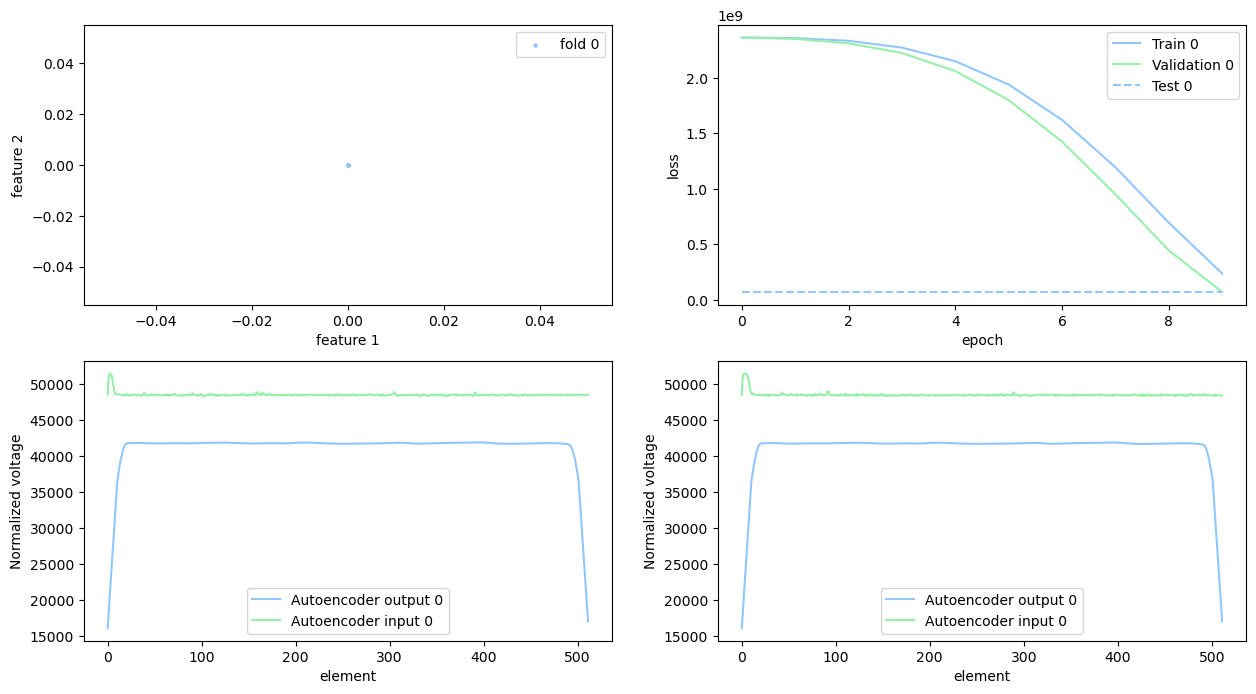

In [16]:
experiment.load_results("run-2023-06-27-11-53")